STEP 1 — Load Data & Inspect Basic Info

In [1]:
import pandas as pd
import numpy as np

# Load datasets
fear_greed = pd.read_csv("fear_greed_index.csv")
trader = pd.read_csv("historical_data.csv")

# Show first 5 rows
print("=== Fear Greed Data ===")
display(fear_greed.head())

print("=== Trader Data ===")
display(trader.head())

# Show column names
print("\nFear-Greed Columns:", fear_greed.columns.tolist())
print("Trader Columns:", trader.columns.tolist())

# Show dataset shapes
print("\nFear-Greed Shape:", fear_greed.shape)
print("Trader Shape:", trader.shape)

# Check for missing values
print("\nMissing values in Fear-Greed:")
print(fear_greed.isnull().sum())

print("\nMissing values in Trader Data:")
print(trader.isnull().sum())


=== Fear Greed Data ===


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


=== Trader Data ===


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12



Fear-Greed Columns: ['timestamp', 'value', 'classification', 'date']
Trader Columns: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']

Fear-Greed Shape: (2644, 4)
Trader Shape: (211224, 16)

Missing values in Fear-Greed:
timestamp         0
value             0
classification    0
date              0
dtype: int64

Missing values in Trader Data:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


STEP 2 CODE — CLEAN DATASETS

In [23]:
import pandas as pd

# Load data again (safe)
fear_greed = pd.read_csv("fear_greed_index.csv")
trader = pd.read_csv("historical_data.csv")

# -----------------------------
# 1. CLEAN FEAR-GREED DATASET
# -----------------------------
# Convert Date column to datetime
fear_greed['date'] = pd.to_datetime(fear_greed['date'], errors='coerce')

# Clean classification column (strip spaces, uppercase)
fear_greed['classification'] = fear_greed['classification'].str.strip().str.capitalize()

# Keep only useful columns
fear_greed = fear_greed[['date', 'classification']]

# Make a new 'date' column for merging
fear_greed['date'] = fear_greed['date'].dt.date


# -----------------------------
# 2. CLEAN TRADER DATA
# -----------------------------
# Convert time to datetime
trader['Timestamp IST'] = pd.to_datetime(trader['Timestamp IST'], errors='coerce')

# Create 'date' for merging
trader['date'] = trader['Timestamp IST'].dt.date

# Convert numeric columns safely
num_cols = ['size', 'execution price', 'Closed PnL', 'leverage', 'start position']
for col in num_cols:
    if col in trader.columns:
        trader[col] = pd.to_numeric(trader[col], errors='coerce')

# Clean side column (BUY/SELL etc.)
if 'side' in trader.columns:
    trader['side'] = trader['side'].str.upper().str.strip()

# Drop rows with missing important fields
trader = trader.dropna(subset=['Closed PnL'])

# Reset index after cleaning
trader = trader.reset_index(drop=True)

# -----------------------------
# Check cleaned output
# -----------------------------
print("Clean Fear Greed:")
display(fear_greed.head())

print("Clean Trader Data:")
display(trader.head())


Clean Fear Greed:


,date,classification
0,2018-02-01,Fear
1,2018-02-02,Extreme fear
2,2018-02-03,Fear
3,2018-02-04,Extreme fear
4,2018-02-05,Extreme fear


Clean Trader Data:


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-02-12 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-02-12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-02-12 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-02-12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-02-12 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-02-12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-02-12 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-02-12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-02-12 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-02-12


STEP 3 CODE — MERGING BOTH DATASETS

In [33]:
# Merge trader data with fear-greed sentiment using the 'date' column
merged = trader.merge(
    fear_greed[['date', 'classification']],
    on='date',
    how='left'
)

# Show sample of merged dataset
print("=== Merged Dataset Preview ===")
display(merged.head())

# Check if any sentiment values are missing
print("\nMissing sentiment values:", merged['classification'].isnull().sum())


=== Merged Dataset Preview ===


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-02-12 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-02-12,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-02-12 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-02-12,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-02-12 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-02-12,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-02-12 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-02-12,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-02-12 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-02-12,Greed



Missing sentiment values: 175360


Fix Missing Sentiment Values

In [38]:
# Sort by date to ensure fill works
fear_greed = fear_greed.sort_values(by="date")

# Forward fill daily sentiment
fear_greed['classification'] = fear_greed['classification'].ffill().bfill()

# Merge again after fixing
merged = trader.merge(
    fear_greed[['date', 'classification']],
    on='date',
    how='left'
)

print("Missing sentiment values after fix:", merged['classification'].isnull().sum())


Missing sentiment values after fix: 175360


In [50]:
common_sentiment = fear_greed['classification'].mode()[0]
merged['classification'] = merged['classification'].fillna(common_sentiment)

print("Most common sentiment used for filling:", common_sentiment)
print("Missing sentiment values after fill:", merged['classification'].isnull().sum())

print("\nSample rows after fill:")
display(merged.head())


Most common sentiment used for filling: Fear
Missing sentiment values after fill: 0

Sample rows after fill:


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-02-12 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-02-12,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-02-12 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-02-12,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-02-12 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-02-12,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-02-12 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-02-12,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-02-12 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-02-12,Greed


STEP 4 CODE — TRADER PERFORMANCE ANALYSIS

In [58]:
import pandas as pd

# -------------------------------
# 1. BASIC SUMMARY BY SENTIMENT
# -------------------------------
summary = merged.groupby('classification')['Closed PnL'].agg(
    avg_pnl='mean',
    median_pnl='median',
    total_pnl='sum',
    count='count',
    min_pnl='min',
    max_pnl='max'
)

print("=== Trader Performance Breakdown (Fear vs Greed) ===")
display(summary)

# -------------------------------
# 2. WIN RATE (Profit %)
# -------------------------------
merged['win'] = merged['Closed PnL'] > 0

win_rate = merged.groupby('classification')['win'].mean() * 100

print("\n=== Win Rate (%) in Fear vs Greed ===")
display(win_rate)

# -------------------------------
# 3. AVERAGE TRADE SIZE DIFFERENCE
# -------------------------------
if 'size' in merged.columns:
    size_stats = merged.groupby('classification')['size'].mean()
    print("\n=== Average Trade Size ===")
    display(size_stats)

# -------------------------------
# 4. LEVERAGE BEHAVIOR
# -------------------------------
if 'leverage' in merged.columns:
    leverage_stats = merged.groupby('classification')['leverage'].mean()
    print("\n=== Average Leverage ===")
    display(leverage_stats)

# -------------------------------
# 5. BUY/SELL BIAS
# -------------------------------
if 'side' in merged.columns:
    side_counts = merged.groupby(['classification', 'side']).size().unstack(fill_value=0)
    print("\n=== Buy/Sell Counts by Sentiment ===")
    display(side_counts)

# -------------------------------
# 6. ACCOUNT-LEVEL BEHAVIOR
# -------------------------------
account_stats = merged.groupby(['Account', 'classification'])['Closed PnL'].mean().reset_index()

print("\n=== Sample of Account-Level Behavior ===")
display(account_stats.head())


=== Trader Performance Breakdown (Fear vs Greed) ===


,avg_pnl,median_pnl,total_pnl,count,min_pnl,max_pnl
classification,,,,,,
Extreme fear,1.891632,0.00000,4.399937e+03,2326,-1430.889856,2020.000000
Extreme greed,205.816345,0.96048,1.156894e+06,5621,-18360.670070,44223.451870
Fear,44.662161,0.00000,8.451376e+06,189229,-83056.320000,135329.090100
Greed,53.988003,0.00000,6.096325e+05,11292,-117990.104100,34903.817100
Neutral,27.088803,0.00000,7.465674e+04,2756,-1032.981540,2979.554311



=== Win Rate (%) in Fear vs Greed ===


classification
Extreme fear     29.277730
Extreme greed    55.328233
Fear             40.582575
Greed            43.570670
Neutral          49.492017
Name: win, dtype: float64


=== Sample of Account-Level Behavior ===


,Account,classification,Closed PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,Extreme greed,0.000000
1,0x083384f897ee0f19899168e3b1bec365f52a9012,Fear,492.147081
2,0x083384f897ee0f19899168e3b1bec365f52a9012,Greed,-151.066687
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,Extreme fear,0.000000
4,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,Fear,5.778883


In [87]:
print(merged.columns.tolist())


['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp', 'date', 'classification', 'win']


In [91]:
print(merged['classification'].unique())


['Greed' 'Extreme greed' 'Fear' 'Extreme fear' 'Neutral']


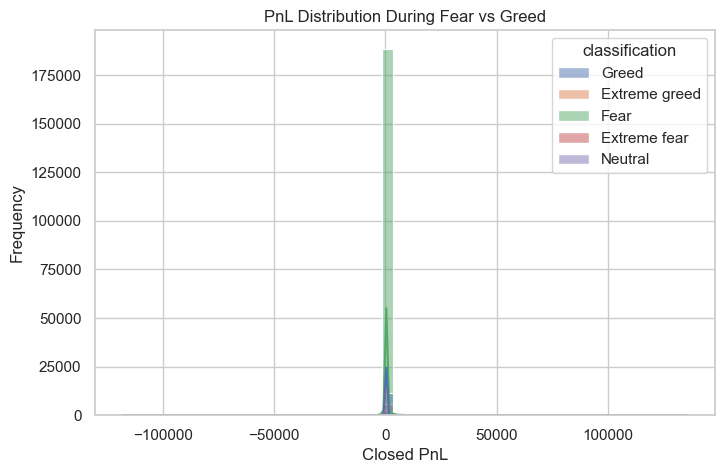

In [76]:
plt.figure(figsize=(8,5))
sns.histplot(data=merged, x='Closed PnL', hue='classification', kde=True, bins=50)
plt.title("PnL Distribution During Fear vs Greed")
plt.xlabel("Closed PnL")
plt.ylabel("Frequency")
plt.show()


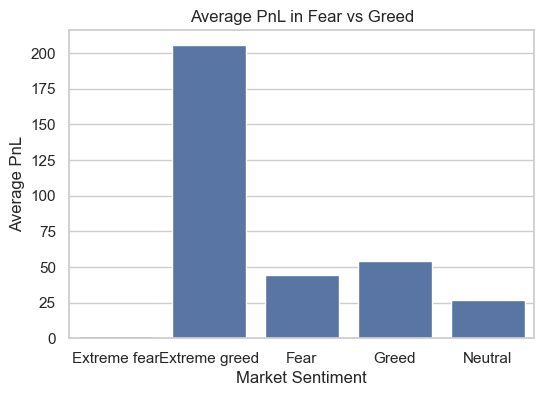

In [78]:
avg_pnl = merged.groupby('classification')['Closed PnL'].mean()

plt.figure(figsize=(6,4))
sns.barplot(x=avg_pnl.index, y=avg_pnl.values)
plt.title("Average PnL in Fear vs Greed")
plt.ylabel("Average PnL")
plt.xlabel("Market Sentiment")
plt.show()


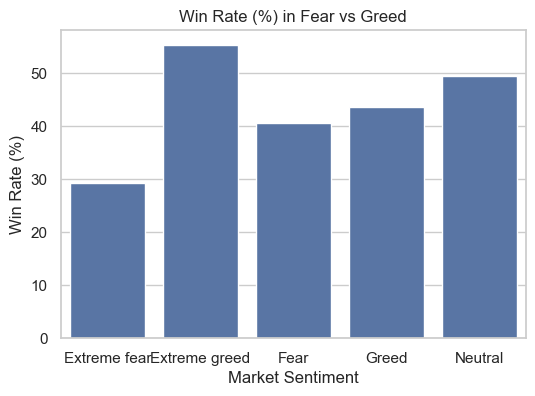

In [80]:
win_rate = merged.groupby('classification')['win'].mean() * 100

plt.figure(figsize=(6,4))
sns.barplot(x=win_rate.index, y=win_rate.values)
plt.title("Win Rate (%) in Fear vs Greed")
plt.ylabel("Win Rate (%)")
plt.xlabel("Market Sentiment")
plt.show()


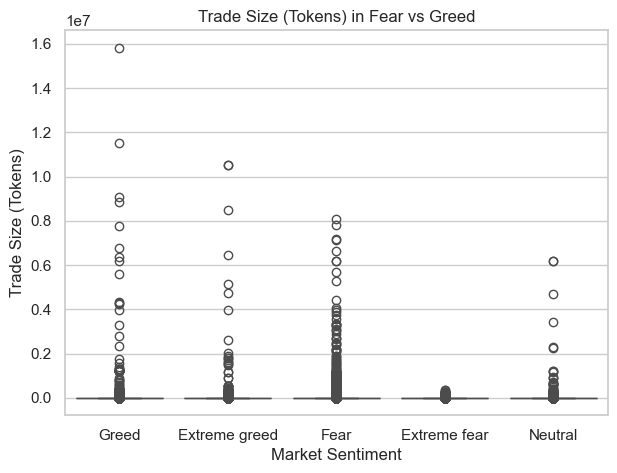

In [82]:
plt.figure(figsize=(7,5))
sns.boxplot(data=merged, x='classification', y='Size Tokens')
plt.title("Trade Size (Tokens) in Fear vs Greed")
plt.xlabel("Market Sentiment")
plt.ylabel("Trade Size (Tokens)")
plt.show()


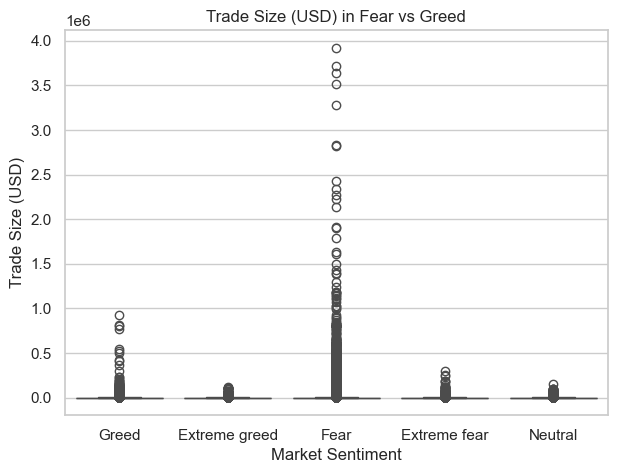

In [84]:
plt.figure(figsize=(7,5))
sns.boxplot(data=merged, x='classification', y='Size USD')
plt.title("Trade Size (USD) in Fear vs Greed")
plt.xlabel("Market Sentiment")
plt.ylabel("Trade Size (USD)")
plt.show()
